In [1]:
# Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time


**10 Classes dataset**

In [4]:
# Download mini subset of ImageNet (10 classes)
import tensorflow_datasets as tfds
dataset_name = "imagenette/160px"  # Lightweight 10-class ImageNet subset

# Load train + validation only
(train_ds, val_ds_full), ds_info = tfds.load(
    dataset_name,
    split=["train", "validation"],
    as_supervised=True,
    with_info=True
)

# Manually create test split from validation (50/50)
val_ds = val_ds_full.take(len(val_ds_full) // 2)
test_ds = val_ds_full.skip(len(val_ds_full) // 2)


In [5]:
# Preprocessing
IMG_SIZE = 299  # Required by Inception architectures
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val   = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test  = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)

NUM_CLASSES = ds_info.features["label"].num_classes


**100 Classes dataset**

In [2]:
# Downloading mini-imageNet dataset from Hugging Face (100 classes)
from datasets import load_dataset

dataset = load_dataset("timm/mini-imagenet")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [11]:
import tensorflow as tf

IMG_SIZE = 299
BATCH_SIZE = 16
SHUFFLE_BUFFER = 500

# Preprocessing function for tf.data.Dataset
def preprocess_tf(example):
    # Convert to float32 and normalize
    img = tf.cast(example["image"], tf.float32) / 255.0
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    label = tf.cast(example["label"], tf.int32)
    return img, label

# Generator: yields examples lazily
def generator_safe_rgb(split_name):
    for ex in dataset[split_name]:
        img = ex["image"]  # PIL Image
        label = ex["label"]

        # Convert to NumPy array
        img = np.array(img)

        # If grayscale (2D), expand dims to (H,W,1)
        if img.ndim == 2:
            img = np.expand_dims(img, axis=-1)

        # If RGBA or more than 3 channels, keep only first 3
        if img.shape[-1] > 3:
            img = img[..., :3]

        # If still 1 channel, convert to RGB by repeating
        if img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)

        yield {"image": img, "label": label}

# Create tf.data.Dataset
def create_tf_dataset(split_name, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: generator_safe_rgb(split_name),
        output_signature={
            "image": tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
            "label": tf.TensorSpec(shape=(), dtype=tf.int64)
        }
    )

    ds = ds.map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(SHUFFLE_BUFFER)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Build datasets
train = create_tf_dataset("train", shuffle=True)
val   = create_tf_dataset("validation")
test  = create_tf_dataset("test")


In [6]:
# Overenie počtu tried
NUM_CLASSES = dataset["train"].features["label"].num_classes
print("Number of classes:", NUM_CLASSES)


Number of classes: 100


In [7]:
# Model building
def build_model(model_name):
    base = tf.keras.applications.__dict__[model_name](
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        weights="imagenet"
    )

    base.trainable = False  # For fast demo training

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [8]:
# Graph plotting
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    # accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="train")
    plt.plot(history.history['val_accuracy'], label="val")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="train")
    plt.plot(history.history['val_loss'], label="val")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


In [9]:
# Printing metrics
def evaluate_model(model, test_dataset):
    y_true = []
    y_pred = []
    latencies = []

    for images, labels in test_dataset:
        start_time = time.time()
        preds = model.predict(images, verbose=0)
        end_time = time.time()

        batch_latency = (end_time - start_time) / len(images)
        latencies.append(batch_latency)

        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    latency_ms = np.mean(latencies) * 1000
    throughput = 1 / np.mean(latencies)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "latency_ms": latency_ms,
        "throughput": throughput,
        "y_true": y_true,
        "y_pred": y_pred
    }


Epoch 1/5
   3125/Unknown 320s 98ms/step - accuracy: 0.9010 - loss: 0.5458

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 379s 116ms/step - accuracy: 0.9010 - loss: 0.5458 - val_accuracy: 0.5342 - val_loss: 2.3011
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 356s 110ms/step - accuracy: 0.9684 - loss: 0.1579 - val_accuracy: 0.8372 - val_loss: 1.0881
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 351s 111ms/step - accuracy: 0.9858 - loss: 0.0686 - val_accuracy: 0.7652 - val_loss: 1.8276
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 346s 110ms/step - accuracy: 0.9871 - loss: 0.0628 - val_accuracy: 0.8372 - val_loss: 1.2823
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 343s 109ms/step - accuracy: 0.9894 - loss: 0.0541 - val_accuracy: 0.7736 - val_loss: 1.9524


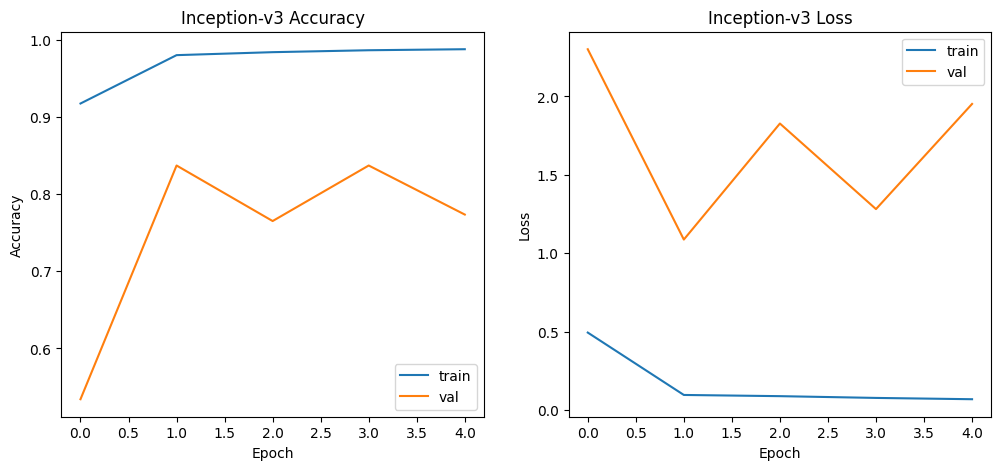

Inception-v3 Metrics:
accuracy: 0.6994
precision: 0.9243626113454319
recall: 0.6994000000000001
f1: 0.7587224892845909
latency_ms: 16.72397096888326
throughput: 59.79441137876926


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
# Inception-v3
model_iv3 = build_model("InceptionV3")

history_iv3 = model_iv3.fit(
    train,
    validation_data=val,
    epochs=5
)

plot_history(history_iv3, "Inception-v3")

results_iv3 = evaluate_model(model_iv3, test)
print("Inception-v3 Metrics:")
for k,v in results_iv3.items():
    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v}")


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5
   3125/Unknown 545s 164ms/step - accuracy: 0.8983 - loss: 0.5866

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 654s 199ms/step - accuracy: 0.8983 - loss: 0.5866 - val_accuracy: 0.8630 - val_loss: 0.7134
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 607s 193ms/step - accuracy: 0.9792 - loss: 0.0839 - val_accuracy: 0.8399 - val_loss: 1.0223
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 607s 193ms/step - accuracy: 0.9894 - loss: 0.0511 - val_accuracy: 0.8428 - val_loss: 1.0753
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 607s 194ms/step - accuracy: 0.9890 - loss: 0.0532 - val_accuracy: 0.8863 - val_loss: 0.8024
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 606s 193ms/step - accuracy: 0.9908 - loss: 0.0463 - val_accuracy: 0.8474 - val_loss: 1.1362


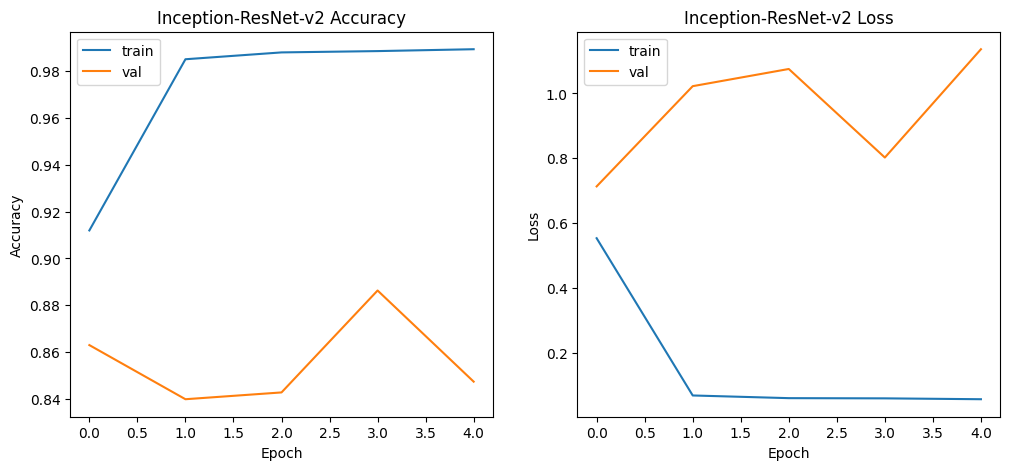


Inception-ResNet-v2 Metrics:
accuracy: 0.779
precision: 0.946006915128609
recall: 0.779
f1: 0.827253511034906
latency_ms: 25.903851841204464
throughput: 38.60429738905975


In [13]:
model_irnv2 = build_model("InceptionResNetV2")

history_irnv2 = model_irnv2.fit(
    train,
    validation_data=val,
    epochs=5
)

plot_history(history_irnv2, "Inception-ResNet-v2")

results_irnv2 = evaluate_model(model_irnv2, test)
print("\nInception-ResNet-v2 Metrics:")
for k,v in results_irnv2.items():
    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v}")